In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [185]:
%%capture
!pip install Lifetimes

In [186]:
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import(
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
    plot_period_transactions
)

In [187]:
import warnings

warnings.filterwarnings("ignore")

In [189]:
raw = pd.read_csv("/content/Online Retail.csv")
raw.columns = raw.columns.str.strip()
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], dayfirst=True, format = "%m/%d/%Y %H:%M")
raw = raw[raw["Quantity"] > 0]
raw = raw[raw["UnitPrice"] > 0]
raw["LineTotal"] = raw["Quantity"] * raw["UnitPrice"]
raw = raw.dropna(subset=["CustomerID"])
raw["CustomerID"] = raw["CustomerID"].astype(int)

In [190]:
observation_data = raw["InvoiceDate"].max()

rfm_summary = summary_data_from_transaction_data(
    raw,
    customer_id_col = "CustomerID",
    datetime_col = "InvoiceDate",
    monetary_value_col = "LineTotal",
    observation_period_end = observation_data,
    freq = "D"
)

In [191]:
rfm_summary = rfm_summary[rfm_summary["frequency"] > 0]

In [192]:
print(f"Customers for CLV modeling: {len(rfm_summary)}")
print(rfm_summary.head())
print(rfm_summary.describe().round(2))

Customers for CLV modeling: 2790
            frequency  recency      T  monetary_value
CustomerID                                           
12347             6.0    365.0  367.0      599.701667
12348             3.0    283.0  358.0      301.480000
12352             6.0    260.0  296.0      368.256667
12356             2.0    303.0  325.0      269.905000
12358             1.0    149.0  150.0      683.200000
       frequency  recency        T  monetary_value
count    2790.00  2790.00  2790.00         2790.00
mean        4.45   203.33   260.12          477.38
std         6.92   111.46   101.48         3245.62
min         1.00     1.00     9.00            1.00
25%         1.00   106.00   197.25          187.25
50%         3.00   211.00   284.00          309.47
75%         5.00   301.75   358.00          458.37
max       131.00   373.00   373.00       168469.60


In [193]:
bgf = BetaGeoFitter(penalizer_coef = 0.01)
bgf.fit(
    rfm_summary["frequency"],
    rfm_summary["recency"],
    rfm_summary["T"]
)

<lifetimes.BetaGeoFitter: fitted with 2790 subjects, a: 0.01, alpha: 89.90, b: 0.13, r: 1.60>

In [195]:
rfm_summary["predicted_purchases_90d"] =  bgf.conditional_expected_number_of_purchases_up_to_time(
    90,
    rfm_summary["frequency"],
    rfm_summary["recency"],
    rfm_summary["T"]
)

In [196]:
rfm_summary["prob_alive"] = bgf.conditional_probability_alive(
    rfm_summary["frequency"],
    rfm_summary["recency"],
    rfm_summary["T"]
)

In [197]:
corr = rfm_summary[["frequency", "monetary_value"]].corr().iloc[0, 1]
print(f"\nFrequency-Monetary correlation: {corr:.4f}")
print("Should be low (<0.3) for Gamma-Gamma assumption to hold")


Frequency-Monetary correlation: 0.0159
Should be low (<0.3) for Gamma-Gamma assumption to hold


In [198]:
ggf = GammaGammaFitter(penalizer_coef = 0.01)
ggf.fit(
    rfm_summary["frequency"],
    rfm_summary["monetary_value"]
)

<lifetimes.GammaGammaFitter: fitted with 2790 subjects, p: 3.75, q: 0.33, v: 3.64>

In [199]:
rfm_summary["clv_12months"] = ggf.customer_lifetime_value(
    bgf,
    rfm_summary["frequency"],
    rfm_summary["recency"],
    rfm_summary["T"],
    rfm_summary["monetary_value"],
    time = 12,
    freq = "D",
    discount_rate = 0.01
)

In [200]:
rfm_summary["clv_segment"] = pd.qcut(
    rfm_summary["clv_12months"],
    q=4,
    labels=["Low CLV", "Medium CLV", "High CLV", "Premium CLV"]
)

In [201]:
print("\nCLV Summary:")
print(rfm_summary["clv_12months"].describe().round(2))
print("\nCLV Segment Distribution:")
print(rfm_summary["clv_segment"].value_counts())


CLV Summary:
count      2790.00
mean       3096.53
std       13759.64
min          12.74
25%         788.95
50%        1520.56
75%        2848.24
max      577587.93
Name: clv_12months, dtype: float64

CLV Segment Distribution:
clv_segment
Low CLV        698
Premium CLV    698
Medium CLV     697
High CLV       697
Name: count, dtype: int64


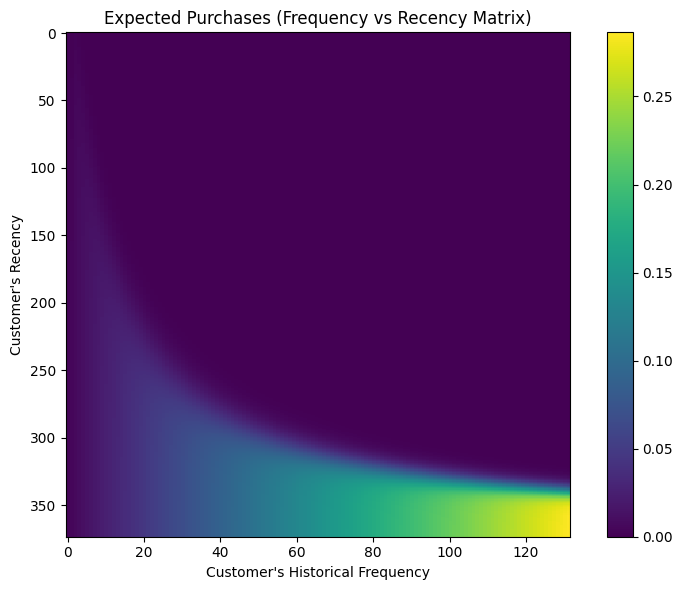

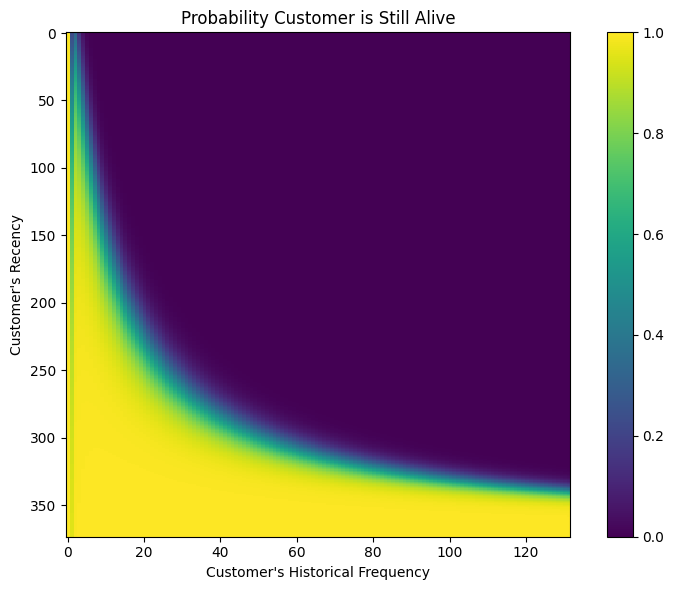

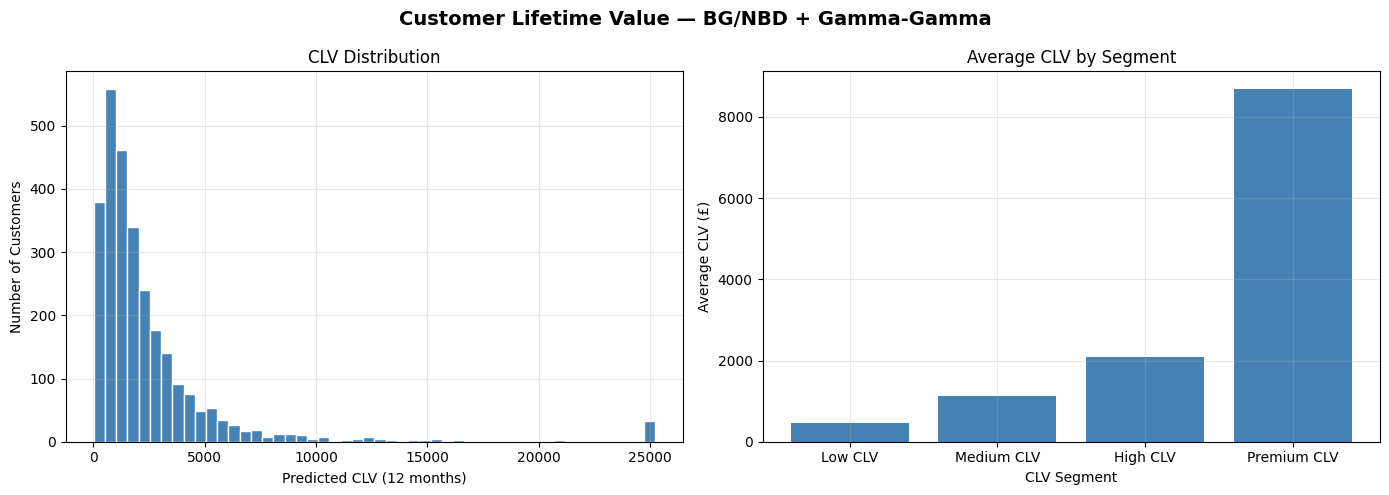

In [205]:
fig1, ax1 = plt.subplots(figsize=(8, 6))
plot_frequency_recency_matrix(bgf)
plt.title("Expected Purchases (Frequency vs Recency Matrix)")
plt.tight_layout()
plt.savefig("clv_frequency_recency.png", dpi=150)
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
plot_probability_alive_matrix(bgf)
plt.title("Probability Customer is Still Alive")
plt.tight_layout()
plt.savefig("clv_prob_alive.png", dpi=150)
plt.show()

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

rfm_summary["clv_12months"].clip(
    upper=rfm_summary["clv_12months"].quantile(0.99)
).hist(bins=50, ax=axes3[0], color="steelblue", edgecolor="white")
axes3[0].set_xlabel("Predicted CLV (12 months)")
axes3[0].set_ylabel("Number of Customers")
axes3[0].set_title("CLV Distribution")
axes3[0].grid(alpha=0.3)

clv_by_segment = rfm_summary.groupby(
    "clv_segment", observed=True
)["clv_12months"].mean().round(2)
axes3[1].bar(clv_by_segment.index, clv_by_segment.values, color="steelblue")
axes3[1].set_xlabel("CLV Segment")
axes3[1].set_ylabel("Average CLV (£)")
axes3[1].set_title("Average CLV by Segment")
axes3[1].grid(alpha=0.3)

plt.suptitle("Customer Lifetime Value — BG/NBD + Gamma-Gamma",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("clv_segments.png", dpi=150)
plt.show()

In [206]:
rfm_summary.to_csv("clv_scored.csv")
print("\nSaved: clv_scored.csv")


Saved: clv_scored.csv
